# UIUC Statistics Datathon 2025 — Call Center Forecasting
## Synchrony | Two-Stage Hierarchical Forecast

In [1]:
# Cell 1: Imports & Config
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import os, json, pickle
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

DATA_DIR = os.getcwd()
EXCEL_FILE = os.path.join(DATA_DIR, 'Data for Datathon (Revised).xlsx')
TEMPLATE_FILE = os.path.join(DATA_DIR, 'template_forecast_v00.csv')
PORTFOLIOS = ['A', 'B', 'C', 'D']
TARGET_METRICS = ['Call Volume', 'CCT', 'Abandon Rate']
print('Setup complete.')

Setup complete.


In [2]:
# Cell 2: Load All Data
xlsx = pd.ExcelFile(EXCEL_FILE)
print('Sheets:', xlsx.sheet_names)

daily_data = {}
for p in PORTFOLIOS:
    df = pd.read_excel(xlsx, f'{p} - Daily')
    df['Date'] = pd.to_datetime(df['Date'].str.strip().str.rsplit(' ', n=1).str[0], format='%m/%d/%y')
    df = df.sort_values('Date').reset_index(drop=True)
    df.columns = [c.strip() for c in df.columns]
    daily_data[p] = df
    print(f'{p} Daily: {df.shape}, {df["Date"].min().date()} to {df["Date"].max().date()}')

month_map = {'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
             'July':7,'August':8,'September':9,'October':10,'November':11,'December':12}
interval_data = {}
for p in PORTFOLIOS:
    df = pd.read_excel(xlsx, f'{p} - Interval')
    df.columns = [c.strip() for c in df.columns]
    df = df.dropna(subset=['Interval']).copy()
    df['month_num'] = df['Month'].map(month_map)
    df['Day'] = df['Day'].astype(int)
    df['Date'] = pd.to_datetime(dict(year=2024, month=df['month_num'], day=df['Day']))
    df['slot'] = df['Interval'].apply(lambda t: t.hour * 2 + t.minute // 30)
    df = df.sort_values(['Date', 'slot']).reset_index(drop=True)
    interval_data[p] = df
    print(f'{p} Interval: {df.shape}, {df["Date"].min().date()} to {df["Date"].max().date()}')

staffing_df = pd.read_excel(xlsx, 'Daily Staffing')
staffing_df.columns = ['Date'] + [f'Staff_{p}' for p in PORTFOLIOS]
staffing_df['Date'] = pd.to_datetime(staffing_df['Date'])
staffing_df = staffing_df.sort_values('Date').reset_index(drop=True)
print(f'Staffing: {staffing_df.shape}, {staffing_df["Date"].min().date()} to {staffing_df["Date"].max().date()}')

template_df = pd.read_csv(TEMPLATE_FILE)
print(f'Template: {template_df.shape}')

Sheets: ['A - Daily', 'A - Interval', 'B - Daily', 'B - Interval', 'C - Daily', 'C - Interval', 'D - Daily', 'D - Interval', 'Daily Staffing', 'Definitions']
A Daily: (731, 5), 2024-01-01 to 2025-12-31
B Daily: (731, 5), 2024-01-01 to 2025-12-31
C Daily: (731, 5), 2024-01-01 to 2025-12-31
D Daily: (731, 5), 2024-01-01 to 2025-12-31


A Interval: (4076, 11), 2024-04-01 to 2024-06-30
B Interval: (4285, 11), 2024-04-01 to 2024-06-30


C Interval: (4359, 11), 2024-04-01 to 2024-06-30
D Interval: (4358, 11), 2024-04-01 to 2024-06-30
Staffing: (365, 5), 2025-01-01 to 2025-12-31
Template: (1488, 19)


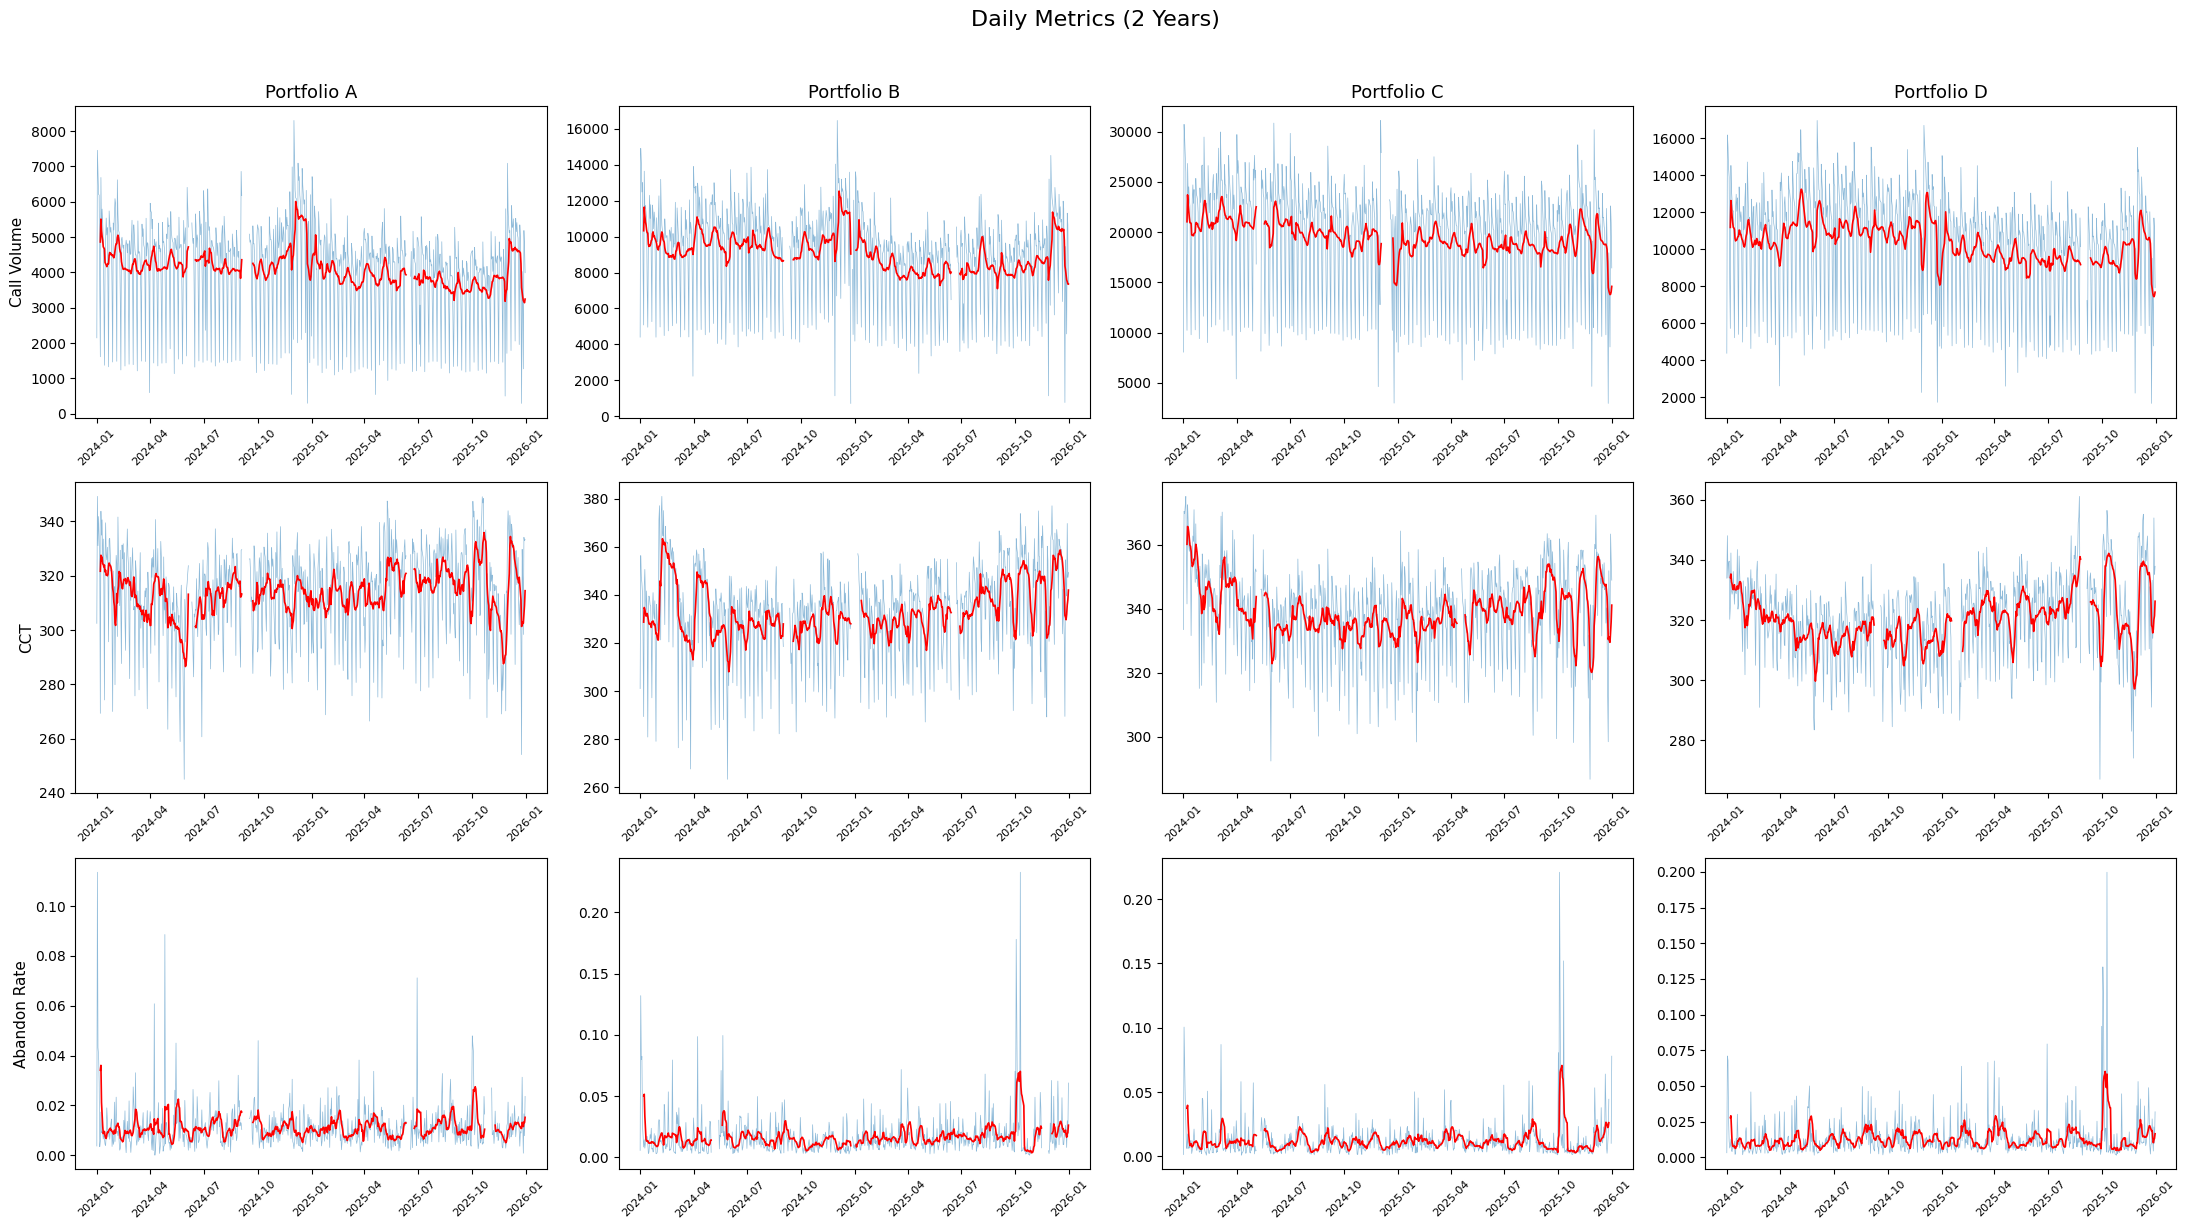

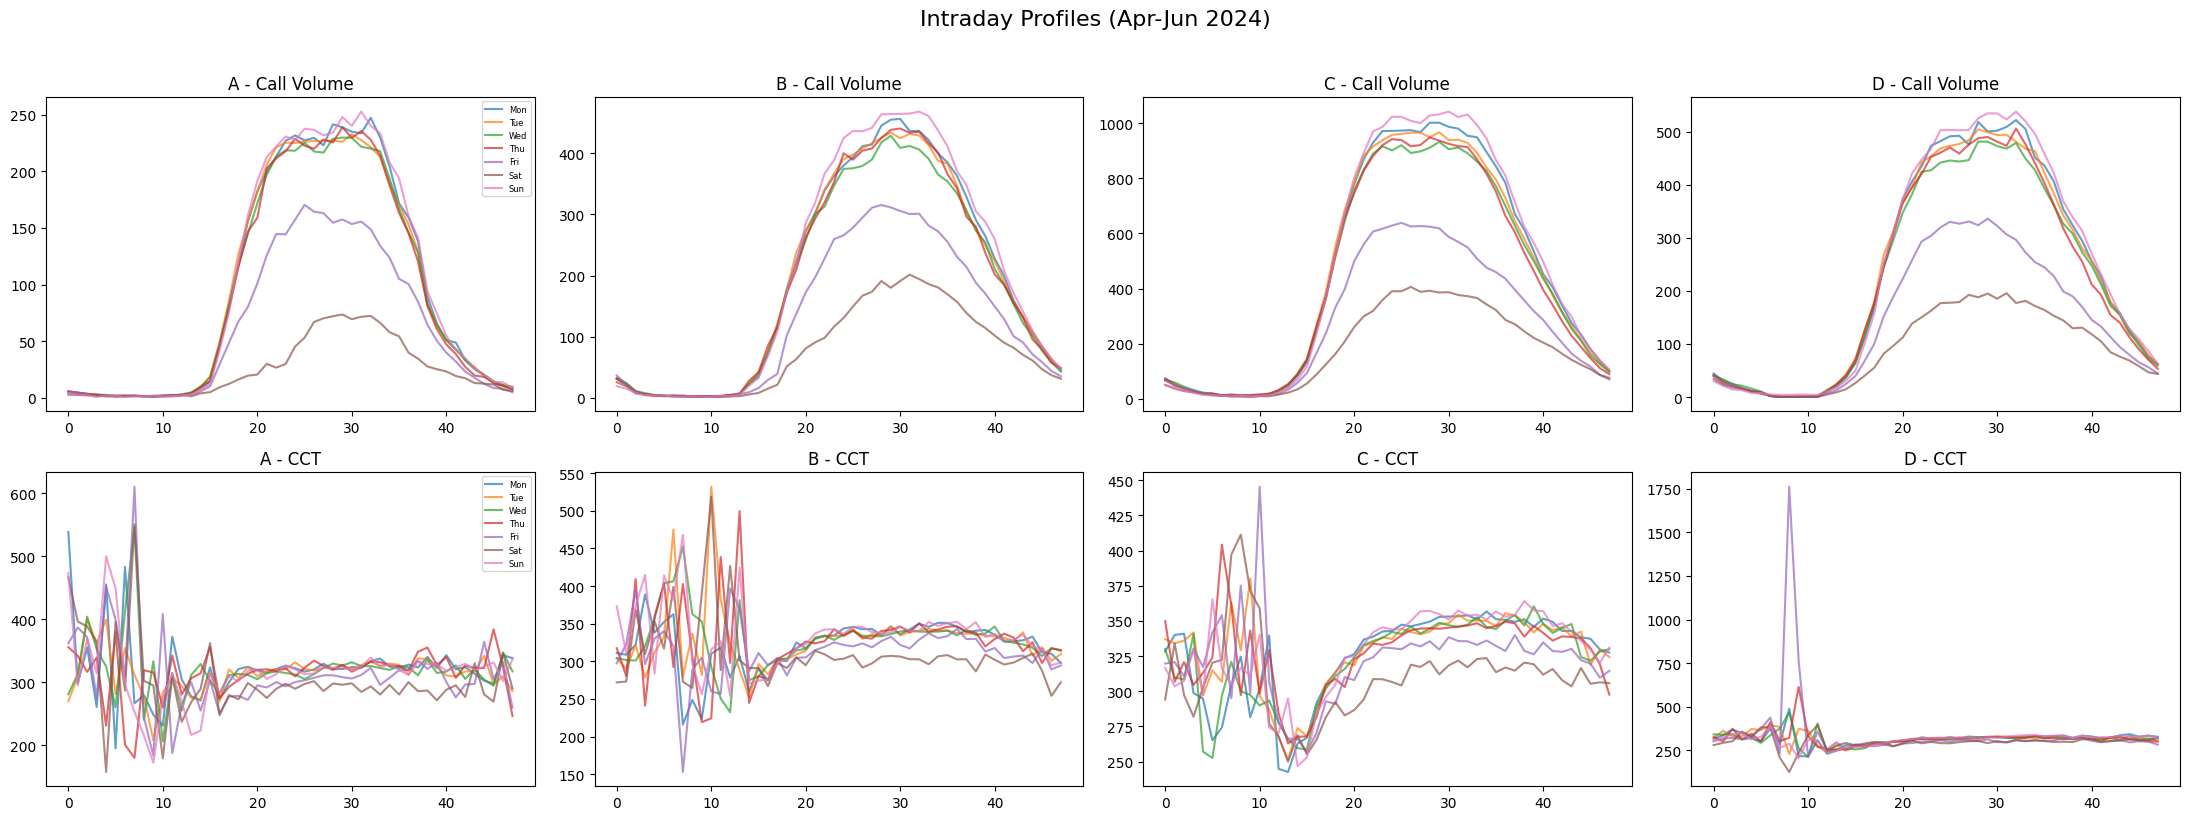


=== YoY Growth (Jan-Jul) ===
  A Call Volume: 2024=4331.3, 2025=3909.7, growth=0.903
  A CCT: 2024=311.0, 2025=314.7, growth=1.012
  A Abandon Rate: 2024=0.0, 2025=0.0, growth=0.907
  B Call Volume: 2024=9629.7, 2025=8351.4, growth=0.867
  B CCT: 2024=331.6, 2025=330.4, growth=0.996
  B Abandon Rate: 2024=0.0, 2025=0.0, growth=0.950
  C Call Volume: 2024=20923.6, 2025=18835.8, growth=0.900
  C CCT: 2024=341.9, 2025=337.7, growth=0.988
  C Abandon Rate: 2024=0.0, 2025=0.0, growth=0.932
  D Call Volume: 2024=10980.5, 2025=9702.3, growth=0.884
  D CCT: 2024=319.0, 2025=321.5, growth=1.008
  D Abandon Rate: 2024=0.0, 2025=0.0, growth=1.099


In [3]:
# Cell 3: EDA
fig, axes = plt.subplots(3, 4, figsize=(22, 12), sharex='row')
fig.suptitle('Daily Metrics (2 Years)', fontsize=16, y=1.02)
for ci, p in enumerate(PORTFOLIOS):
    df = daily_data[p]
    for ri, m in enumerate(TARGET_METRICS):
        ax = axes[ri, ci]
        ax.plot(df['Date'], df[m], alpha=0.5, linewidth=0.5)
        ax.plot(df['Date'], df[m].rolling(7).mean(), color='red', linewidth=1.2)
        if ri == 0: ax.set_title(f'Portfolio {p}', fontsize=13)
        if ci == 0: ax.set_ylabel(m, fontsize=11)
        ax.tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(22, 8))
fig.suptitle('Intraday Profiles (Apr-Jun 2024)', fontsize=16, y=1.02)
dow_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
for ci, p in enumerate(PORTFOLIOS):
    df = interval_data[p].copy()
    df['dow'] = df['Date'].dt.dayofweek
    for ri, m in enumerate(['Call Volume', 'CCT']):
        ax = axes[ri, ci]
        for dow in range(7):
            prof = df[df['dow']==dow].groupby('slot')[m].mean()
            ax.plot(prof.index, prof.values, label=dow_names[dow], alpha=0.7)
        ax.set_title(f'{p} - {m}')
        if ci == 0: ax.legend(fontsize=6)
plt.tight_layout()
plt.show()

print('\n=== YoY Growth (Jan-Jul) ===')
for p in PORTFOLIOS:
    df = daily_data[p]
    for m in TARGET_METRICS:
        d24 = df[(df['Date'].dt.year==2024) & (df['Date'].dt.month<=7)][m].mean()
        d25 = df[(df['Date'].dt.year==2025) & (df['Date'].dt.month<=7)][m].mean()
        print(f'  {p} {m}: 2024={d24:.1f}, 2025={d25:.1f}, growth={d25/d24:.3f}')

In [4]:
# Cell 4: Feature Engineering
US_HOLIDAYS = pd.to_datetime(['2024-01-01','2024-01-15','2024-02-19','2024-05-27','2024-06-19',
    '2024-07-04','2024-09-02','2024-10-14','2024-11-11','2024-11-28','2024-12-25',
    '2025-01-01','2025-01-20','2025-02-17','2025-05-26','2025-06-19',
    '2025-07-04','2025-09-01','2025-10-13','2025-11-11','2025-11-27','2025-12-25'])

def build_daily_features(df, portfolio, staffing_df=None):
    feat = pd.DataFrame(index=df.index)
    feat['Date'] = df['Date']
    feat['day_of_week'] = df['Date'].dt.dayofweek
    feat['day_of_month'] = df['Date'].dt.day
    feat['month'] = df['Date'].dt.month
    feat['week_of_year'] = df['Date'].dt.isocalendar().week.astype(int)
    feat['quarter'] = df['Date'].dt.quarter
    feat['year'] = df['Date'].dt.year
    feat['is_weekend'] = (feat['day_of_week'] >= 5).astype(int)
    feat['is_monday'] = (feat['day_of_week'] == 0).astype(int)
    feat['is_friday'] = (feat['day_of_week'] == 4).astype(int)
    feat['dow_sin'] = np.sin(2*np.pi*feat['day_of_week']/7)
    feat['dow_cos'] = np.cos(2*np.pi*feat['day_of_week']/7)
    feat['dom_sin'] = np.sin(2*np.pi*feat['day_of_month']/31)
    feat['dom_cos'] = np.cos(2*np.pi*feat['day_of_month']/31)
    feat['month_sin'] = np.sin(2*np.pi*feat['month']/12)
    feat['month_cos'] = np.cos(2*np.pi*feat['month']/12)
    feat['is_holiday'] = df['Date'].isin(US_HOLIDAYS).astype(int)
    holiday_arr = US_HOLIDAYS.values
    ds_list, du_list = [], []
    for d in df['Date'].values:
        past = holiday_arr[holiday_arr <= d]
        future = holiday_arr[holiday_arr >= d]
        ds_list.append((d - past[-1])/np.timedelta64(1,'D') if len(past)>0 else 365)
        du_list.append((future[0] - d)/np.timedelta64(1,'D') if len(future)>0 else 365)
    feat['days_since_holiday'] = ds_list
    feat['days_until_holiday'] = du_list
    feat['is_month_start_week'] = (feat['day_of_month'] <= 5).astype(int)
    feat['is_month_end_week'] = (feat['day_of_month'] >= 26).astype(int)
    feat['is_first_of_month'] = (feat['day_of_month'] == 1).astype(int)
    day_idx = (df['Date'] - df['Date'].min()).dt.days
    for k in range(1, 4):
        feat[f'fw_sin_{k}'] = np.sin(2*np.pi*k*day_idx/7)
        feat[f'fw_cos_{k}'] = np.cos(2*np.pi*k*day_idx/7)
        feat[f'fy_sin_{k}'] = np.sin(2*np.pi*k*day_idx/365.25)
        feat[f'fy_cos_{k}'] = np.cos(2*np.pi*k*day_idx/365.25)
    for m in TARGET_METRICS:
        if m in df.columns:
            feat[f'{m}_lag7'] = df[m].shift(7)
            feat[f'{m}_lag14'] = df[m].shift(14)
            feat[f'{m}_lag28'] = df[m].shift(28)
            feat[f'{m}_lag365'] = df[m].shift(365)
            feat[f'{m}_roll7'] = df[m].rolling(7).mean()
            feat[f'{m}_roll14'] = df[m].rolling(14).mean()
            feat[f'{m}_roll30'] = df[m].rolling(30).mean()
            feat[f'{m}_std7'] = df[m].rolling(7).std()
            feat[f'{m}_ewm7'] = df[m].ewm(span=7).mean()
    if staffing_df is not None:
        scol = f'Staff_{portfolio}'
        feat = feat.merge(staffing_df[['Date', scol]].rename(columns={scol:'num_agents'}), on='Date', how='left')
        feat['agents_change'] = feat['num_agents'].diff()
    for m in TARGET_METRICS:
        if m in df.columns:
            feat[f'target_{m}'] = df[m]
    return feat

feature_data = {}
for p in PORTFOLIOS:
    feature_data[p] = build_daily_features(daily_data[p], p, staffing_df)
    print(f'Portfolio {p}: {feature_data[p].shape}')

Portfolio A: (731, 66)
Portfolio B: (731, 66)
Portfolio C: (731, 66)
Portfolio D: (731, 66)


A profile mean CCT: 306.2s
B profile mean CCT: 329.7s
C profile mean CCT: 336.2s
D profile mean CCT: 315.0s


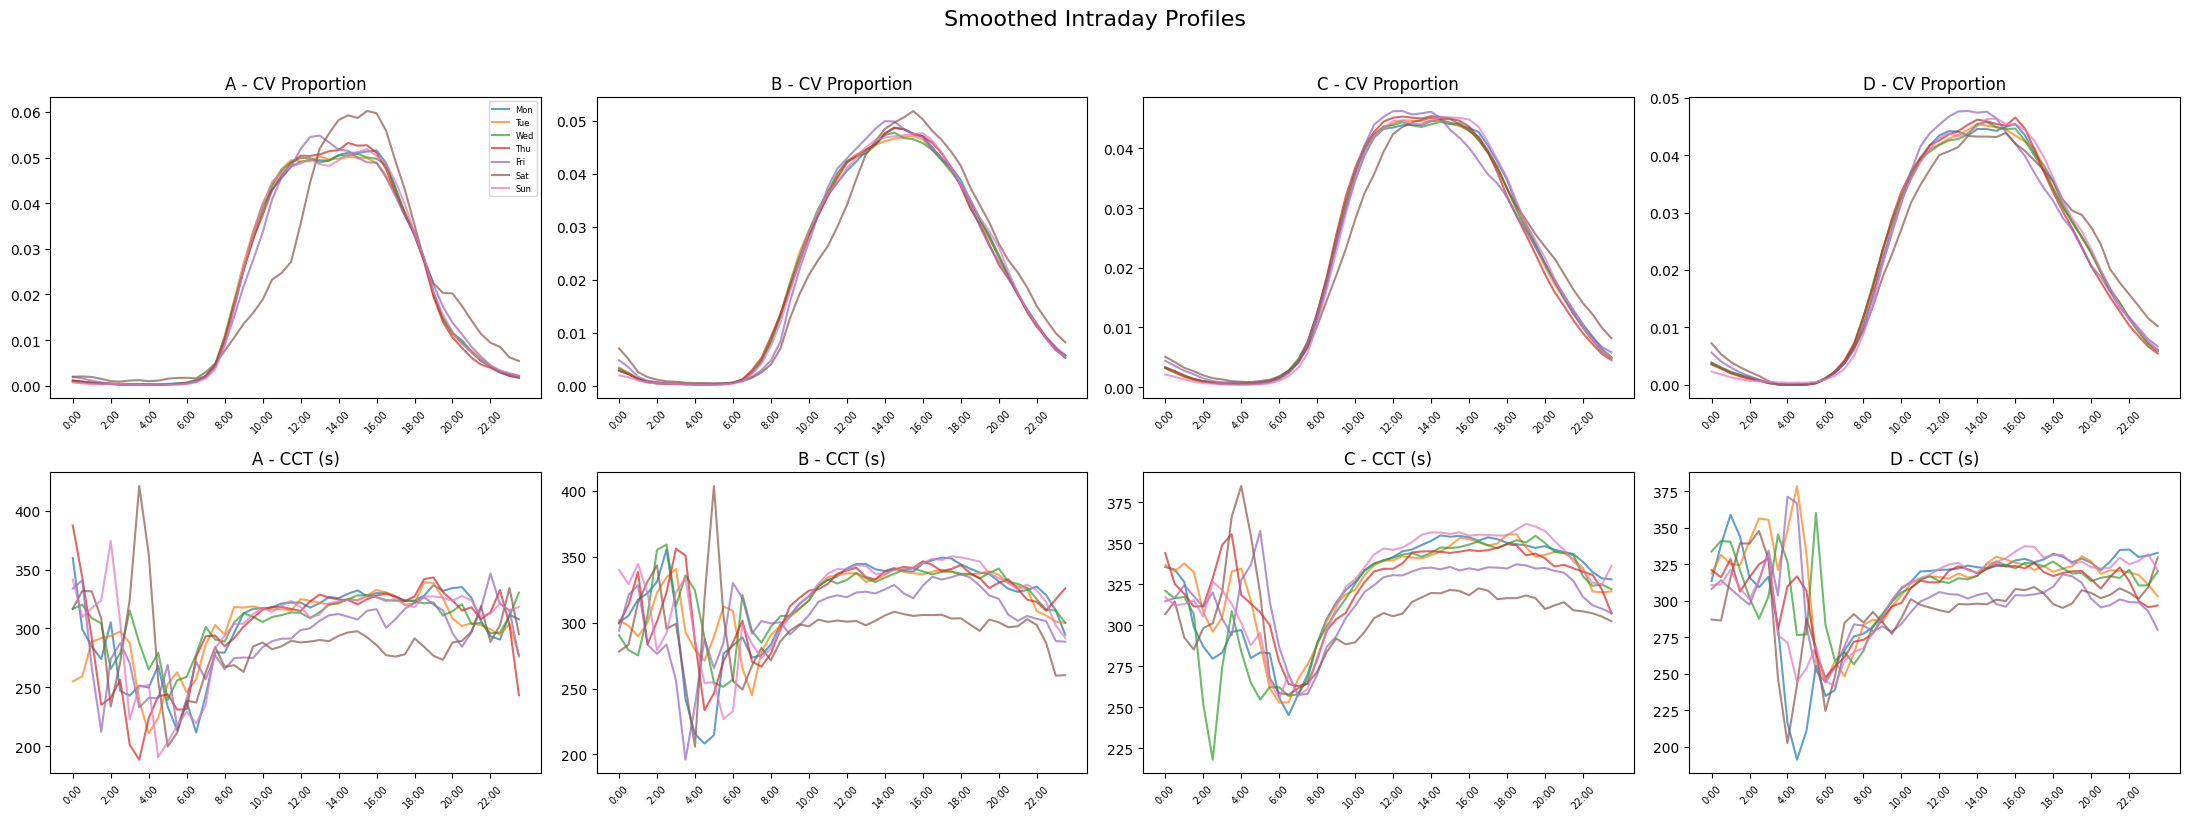

In [5]:
# Cell 5: Intraday Profile Extraction
def build_intraday_profiles(interval_data, portfolios, sigma=0.7):
    cv_profiles, abd_profiles, cct_profiles = {}, {}, {}
    for p in portfolios:
        df = interval_data[p].copy()
        df['dow'] = df['Date'].dt.dayofweek
        daily_cv = df.groupby('Date')['Call Volume'].transform('sum')
        daily_abd = df.groupby('Date')['Abandoned Calls'].transform('sum')
        df['cv_prop'] = df['Call Volume'] / daily_cv.replace(0, np.nan)
        df['abd_prop'] = df['Abandoned Calls'] / daily_abd.replace(0, np.nan)
        cv_profiles[p], abd_profiles[p], cct_profiles[p] = {}, {}, {}
        for dow in range(7):
            sub = df[df['dow']==dow]
            for col, store in [('cv_prop', cv_profiles), ('abd_prop', abd_profiles)]:
                prof = sub.groupby('slot')[col].median()
                arr = np.zeros(48)
                arr[prof.index.astype(int)] = prof.values
                arr = np.nan_to_num(arr, 0)
                if sigma > 0: arr = gaussian_filter1d(arr, sigma=sigma)
                if arr.sum() > 0: arr /= arr.sum()
                store[p][dow] = arr
            prof = sub.groupby('slot')['CCT'].median()
            arr = np.zeros(48)
            arr[prof.index.astype(int)] = prof.values
            arr = np.nan_to_num(arr, 0)
            if sigma > 0: arr = gaussian_filter1d(arr, sigma=sigma)
            cct_profiles[p][dow] = arr
    return cv_profiles, abd_profiles, cct_profiles

cv_profiles, abd_profiles, cct_profiles = build_intraday_profiles(interval_data, PORTFOLIOS)

profile_period_mean_cct = {}
for p in PORTFOLIOS:
    mask = (daily_data[p]['Date']>='2024-04-01') & (daily_data[p]['Date']<='2024-06-30')
    profile_period_mean_cct[p] = daily_data[p].loc[mask, 'CCT'].mean()
    print(f'{p} profile mean CCT: {profile_period_mean_cct[p]:.1f}s')

fig, axes = plt.subplots(2, 4, figsize=(22, 8))
fig.suptitle('Smoothed Intraday Profiles', fontsize=16, y=1.02)
dow_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
tlabels = [f'{h}:{m:02d}' for h in range(24) for m in [0,30]]
for ci, p in enumerate(PORTFOLIOS):
    for dow in range(7):
        axes[0,ci].plot(range(48), cv_profiles[p][dow], label=dow_names[dow], alpha=0.7)
        axes[1,ci].plot(range(48), cct_profiles[p][dow], label=dow_names[dow], alpha=0.7)
    axes[0,ci].set_title(f'{p} - CV Proportion')
    axes[1,ci].set_title(f'{p} - CCT (s)')
    for r in range(2):
        axes[r,ci].set_xticks(range(0,48,4))
        axes[r,ci].set_xticklabels([tlabels[i] for i in range(0,48,4)], rotation=45, fontsize=7)
axes[0,0].legend(fontsize=6)
plt.tight_layout()
plt.show()

In [6]:
# Cell 6: Train Models + Predict August 2025
QUANTILE = 0.55

def get_feature_cols(feat_df):
    exclude = ['Date'] + [f'target_{m}' for m in TARGET_METRICS]
    return [c for c in feat_df.columns if c not in exclude]

daily_predictions = {}
all_scores = {}

for p in PORTFOLIOS:
    print(f'\n{"="*60}\nTraining Portfolio {p}\n{"="*60}')
    feat = feature_data[p]
    fcols = get_feature_cols(feat)
    valid = feat[fcols].notna().all(axis=1)
    clean = feat[valid].copy()
    train_mask = clean['Date'] < '2025-07-01'
    val_mask = (clean['Date'] >= '2025-07-01') & (clean['Date'] < '2025-08-01')
    X_train = clean.loc[train_mask, fcols].values
    X_val = clean.loc[val_mask, fcols].values
    daily_predictions[p] = {}
    all_scores[p] = {}
    for metric in TARGET_METRICS:
        tcol = f'target_{metric}'
        y_train = clean.loc[train_mask, tcol].values
        y_val = clean.loc[val_mask, tcol].values
        
        # For Abandon Rate: use squared_error (not quantile) since values are tiny
        # Quantile regression at q=0.55 pushes small values to 0
        if metric == 'Abandon Rate':
            hgb = HistGradientBoostingRegressor(
                loss='squared_error', max_iter=500, max_depth=4,
                learning_rate=0.03, l2_regularization=2.0, min_samples_leaf=20, random_state=42)
        else:
            hgb = HistGradientBoostingRegressor(
                loss='quantile', quantile=QUANTILE, max_iter=500, max_depth=6,
                learning_rate=0.05, l2_regularization=1.0, min_samples_leaf=10, random_state=42)
        hgb.fit(X_train, y_train)
        
        ridge = Ridge(alpha=1.0)
        ridge.fit(np.nan_to_num(X_train, 0), y_train)
        pred_val = 0.6*hgb.predict(X_val) + 0.4*ridge.predict(np.nan_to_num(X_val, 0))
        mae = mean_absolute_error(y_val, pred_val)
        rmse = np.sqrt(mean_squared_error(y_val, pred_val))
        all_scores[p][metric] = {'mae': mae, 'rmse': rmse}
        print(f'  {metric}: Val MAE={mae:.4f}, RMSE={rmse:.4f}')
        
        # Predict August
        aug_mask = (feat['Date'] >= '2025-08-01') & (feat['Date'] <= '2025-08-31')
        X_aug = feat.loc[aug_mask, fcols].fillna(method='ffill').fillna(method='bfill').fillna(0)
        ensemble = 0.6*hgb.predict(X_aug.values) + 0.4*ridge.predict(np.nan_to_num(X_aug.values, 0))
        
        # Baseline: Aug 2024 x YoY growth (DOW-matched)
        df = daily_data[p]
        aug24 = df[(df['Date'].dt.month==8) & (df['Date'].dt.year==2024)]
        j24 = df[(df['Date'].dt.year==2024) & (df['Date'].dt.month<=7)][metric].mean()
        j25 = df[(df['Date'].dt.year==2025) & (df['Date'].dt.month<=7)][metric].mean()
        growth = j25/j24 if j24 > 0 else 1.0
        aug_dates_range = pd.date_range('2025-08-01','2025-08-31')
        baseline = np.zeros(31)
        for i, d in enumerate(aug_dates_range):
            match = aug24[aug24['Date'].dt.dayofweek == d.dayofweek][metric].values
            baseline[i] = (match.mean()*growth) if len(match)>0 else (aug24[metric].mean()*growth)
        
        # For Abandon Rate: lean heavier on baseline since model struggles with small values
        if metric == 'Abandon Rate':
            final = 0.40*ensemble[:31] + 0.60*baseline
            # Floor: at least half the Aug 2024 rate (never predict zero)
            aug24_mean = aug24[metric].mean()
            final = np.maximum(final, aug24_mean * 0.5)
        else:
            final = 0.70*ensemble[:31] + 0.30*baseline
        
        daily_predictions[p][metric] = final
        print(f'    Aug: mean={final.mean():.4f}, min={final.min():.4f}, max={final.max():.4f}')

print('\nAll models trained.')


Training Portfolio A


  Call Volume: Val MAE=166.6959, RMSE=197.6310
    Aug: mean=3671.5522, min=1332.9446, max=5019.1601


  CCT: Val MAE=9.7911, RMSE=11.1113
    Aug: mean=322.7838, min=305.7341, max=332.3215


  Abandon Rate: Val MAE=0.0058, RMSE=0.0064
    Aug: mean=0.0136, min=0.0100, max=0.0166

Training Portfolio B


  Call Volume: Val MAE=261.3937, RMSE=321.1822
    Aug: mean=7788.6951, min=3756.4321, max=10487.9463


...

  CCT: Val MAE=6.3674, RMSE=7.3016
    Aug: mean=333.2112, min=321.4191, max=345.2274


  Abandon Rate: Val MAE=0.0114, RMSE=0.0125
    Aug: mean=0.0146, min=0.0098, max=0.0209

Training Portfolio D


  Call Volume: Val MAE=683.6064, RMSE=1028.9850
    Aug: mean=9514.9242, min=4736.1840, max=12759.4101


  CCT: Val MAE=5.2589, RMSE=6.3885
    Aug: mean=327.1323, min=318.2668, max=333.7517


  Abandon Rate: Val MAE=0.0077, RMSE=0.0114
    Aug: mean=0.0220, min=0.0169, max=0.0314

All models trained.


In [7]:
# Cell 7: Disaggregate Daily -> 30-min Intervals
aug_dates = pd.date_range('2025-08-01', '2025-08-31', freq='D')
time_labels_48 = [f'{h}:{m:02d}' for h in range(24) for m in [0, 30]]

interval_forecasts = {p: {'cv':[], 'abd':[], 'abd_rate':[], 'cct':[]} for p in PORTFOLIOS}
for p in PORTFOLIOS:
    daily_cv = daily_predictions[p]['Call Volume']
    daily_cct = daily_predictions[p]['CCT']
    daily_abd_rate = daily_predictions[p]['Abandon Rate']
    daily_abd = daily_cv * daily_abd_rate
    for day_idx, date in enumerate(aug_dates):
        dow = date.dayofweek
        cv_int = daily_cv[day_idx] * cv_profiles[p][dow]
        abd_int = daily_abd[day_idx] * abd_profiles[p][dow]
        cct_scale = daily_cct[day_idx] / profile_period_mean_cct[p] if profile_period_mean_cct[p] > 0 else 1.0
        cct_int = cct_profiles[p][dow] * cct_scale
        abd_rate_int = np.where(cv_int > 0, abd_int / cv_int, 0.0)
        interval_forecasts[p]['cv'].append(cv_int)
        interval_forecasts[p]['abd'].append(abd_int)
        interval_forecasts[p]['abd_rate'].append(abd_rate_int)
        interval_forecasts[p]['cct'].append(cct_int)
for p in PORTFOLIOS:
    for key in interval_forecasts[p]:
        interval_forecasts[p][key] = np.array(interval_forecasts[p][key])
for p in PORTFOLIOS:
    cv = interval_forecasts[p]['cv']
    print(f'{p}: shape={cv.shape}, Aug1 sum={cv[0].sum():.0f} vs daily={daily_predictions[p]["Call Volume"][0]:.0f}')

A: shape=(31, 48), Aug1 sum=4229 vs daily=4229
B: shape=(31, 48), Aug1 sum=8663 vs daily=8663
C: shape=(31, 48), Aug1 sum=20471 vs daily=20471
D: shape=(31, 48), Aug1 sum=10503 vs daily=10503


In [8]:
# Cell 8: Post-Processing
# Bias upward — scoring penalizes understaffing more than overstaffing
# A and C are close (2% under) — small bump
# B and D are 7% under — bigger bump needed
BIAS_PER_PORTFOLIO = {'A': 1.10, 'B': 1.18, 'C': 1.10, 'D': 1.18}
BIAS_CCT = 1.05

for p in PORTFOLIOS:
    b = BIAS_PER_PORTFOLIO[p]
    interval_forecasts[p]['cv'] = interval_forecasts[p]['cv'] * b
    interval_forecasts[p]['abd'] = interval_forecasts[p]['abd'] * b
    interval_forecasts[p]['cct'] = interval_forecasts[p]['cct'] * BIAS_CCT

for p in PORTFOLIOS:
    interval_forecasts[p]['cv'] = np.clip(interval_forecasts[p]['cv'], 0, None)
    interval_forecasts[p]['abd'] = np.clip(interval_forecasts[p]['abd'], 0, None)
    interval_forecasts[p]['cct'] = np.clip(interval_forecasts[p]['cct'], 0, None)
    mask = interval_forecasts[p]['abd'] > interval_forecasts[p]['cv']
    interval_forecasts[p]['abd'][mask] = interval_forecasts[p]['cv'][mask]
    cv = interval_forecasts[p]['cv']
    abd = interval_forecasts[p]['abd']
    interval_forecasts[p]['abd_rate'] = np.clip(np.where(cv > 0, abd / cv, 0.0), 0, 1)
    interval_forecasts[p]['cv'] = np.round(interval_forecasts[p]['cv']).astype(int)
    interval_forecasts[p]['abd'] = np.round(interval_forecasts[p]['abd']).astype(int)

print('Post-processing complete.')
for p in PORTFOLIOS:
    cv = interval_forecasts[p]['cv']
    abd = interval_forecasts[p]['abd']
    ar = interval_forecasts[p]['abd_rate']
    cct = interval_forecasts[p]['cct']
    print(f'{p} (bias={BIAS_PER_PORTFOLIO[p]}): CV total={cv.sum():,}, ABD total={abd.sum():,}, '
          f'avg ABD rate={ar[cv>0].mean():.4f}, avg CCT={cct[cct>0].mean():.1f}s')

Post-processing complete.
A (bias=1.1): CV total=125,179, ABD total=1,653, avg ABD rate=0.0342, avg CCT=328.9s
B (bias=1.18): CV total=284,925, ABD total=5,882, avg ABD rate=0.0246, avg CCT=341.5s
C (bias=1.1): CV total=610,101, ABD total=9,196, avg ABD rate=0.0086, avg CCT=332.9s
D (bias=1.18): CV total=348,035, ABD total=7,830, avg ABD rate=0.0160, avg CCT=332.9s


In [9]:
# Cell 9: Generate Submission CSV
rows = []
for day_idx in range(31):
    for slot_idx in range(48):
        h, m = slot_idx // 2, (slot_idx % 2) * 30
        row = {'Month': 'August', 'Day': str(day_idx+1), 'Interval': f'{h}:{m:02d}'}
        for p in PORTFOLIOS:
            row[f'Calls_Offered_{p}'] = int(interval_forecasts[p]['cv'][day_idx, slot_idx])
            row[f'Abandoned_Calls_{p}'] = int(interval_forecasts[p]['abd'][day_idx, slot_idx])
            row[f'Abandoned_Rate_{p}'] = round(float(interval_forecasts[p]['abd_rate'][day_idx, slot_idx]), 6)
            row[f'CCT_{p}'] = round(float(interval_forecasts[p]['cct'][day_idx, slot_idx]), 2)
        rows.append(row)
submission_df = pd.DataFrame(rows)[template_df.columns.tolist()]
output_path = os.path.join(DATA_DIR, 'forecast_v02.csv')
submission_df.to_csv(output_path, index=False)
print(f'Saved: {output_path}')
print(f'Shape: {submission_df.shape} (expected 1488 x 19)')
print(f'Cols match: {submission_df.columns.tolist() == template_df.columns.tolist()}')
print(f'Nulls: {submission_df.isnull().any().any()}')
submission_df.head()

Saved: /Users/chideraibe/Documents/Datathon/forecast_v02.csv
Shape: (1488, 19) (expected 1488 x 19)
Cols match: True
Nulls: False


,Month,Day,Interval,Calls_Offered_A,Abandoned_Calls_A,Abandoned_Rate_A,CCT_A,Calls_Offered_B,Abandoned_Calls_B,Abandoned_Rate_B,CCT_B,Calls_Offered_C,Abandoned_Calls_C,Abandoned_Rate_C,CCT_C,Calls_Offered_D,Abandoned_Calls_D,Abandoned_Rate_D,CCT_D
0,August,1,0:00,9,0,0.0,377.58,49,1,0.011513,327.94,99,0,0.0,332.32,69,0,0.0,335.93
1,August,1,0:30,8,0,0.0,385.56,35,0,0.004424,358.35,80,0,0.0,334.31,50,0,0.0,342.49
2,August,1,1:00,5,0,0.0,301.67,17,0,0.000410,366.43,61,0,0.0,342.68,38,0,0.0,336.12
3,August,1,1:30,3,0,0.0,240.09,9,0,0.000005,316.32,48,0,0.0,335.66,27,0,0.0,329.88
4,August,1,2:00,2,0,0.0,309.82,7,0,0.000000,308.32,33,0,0.0,328.59,19,0,0.0,324.21


VALIDATION
[PASS] Shape: 1488 x 19
[PASS] No nulls
[PASS] All constraints satisfied

--- Aug 2025 Forecast vs Aug 2024 Actual ---
  A: Forecast=125,179, Aug2024=127,759.0, Ratio=0.980
  B: Forecast=284,925, Aug2024=286,317.0, Ratio=0.995
  C: Forecast=610,101, Aug2024=621,313.0, Ratio=0.982
  D: Forecast=348,035, Aug2024=347,005.0, Ratio=1.003


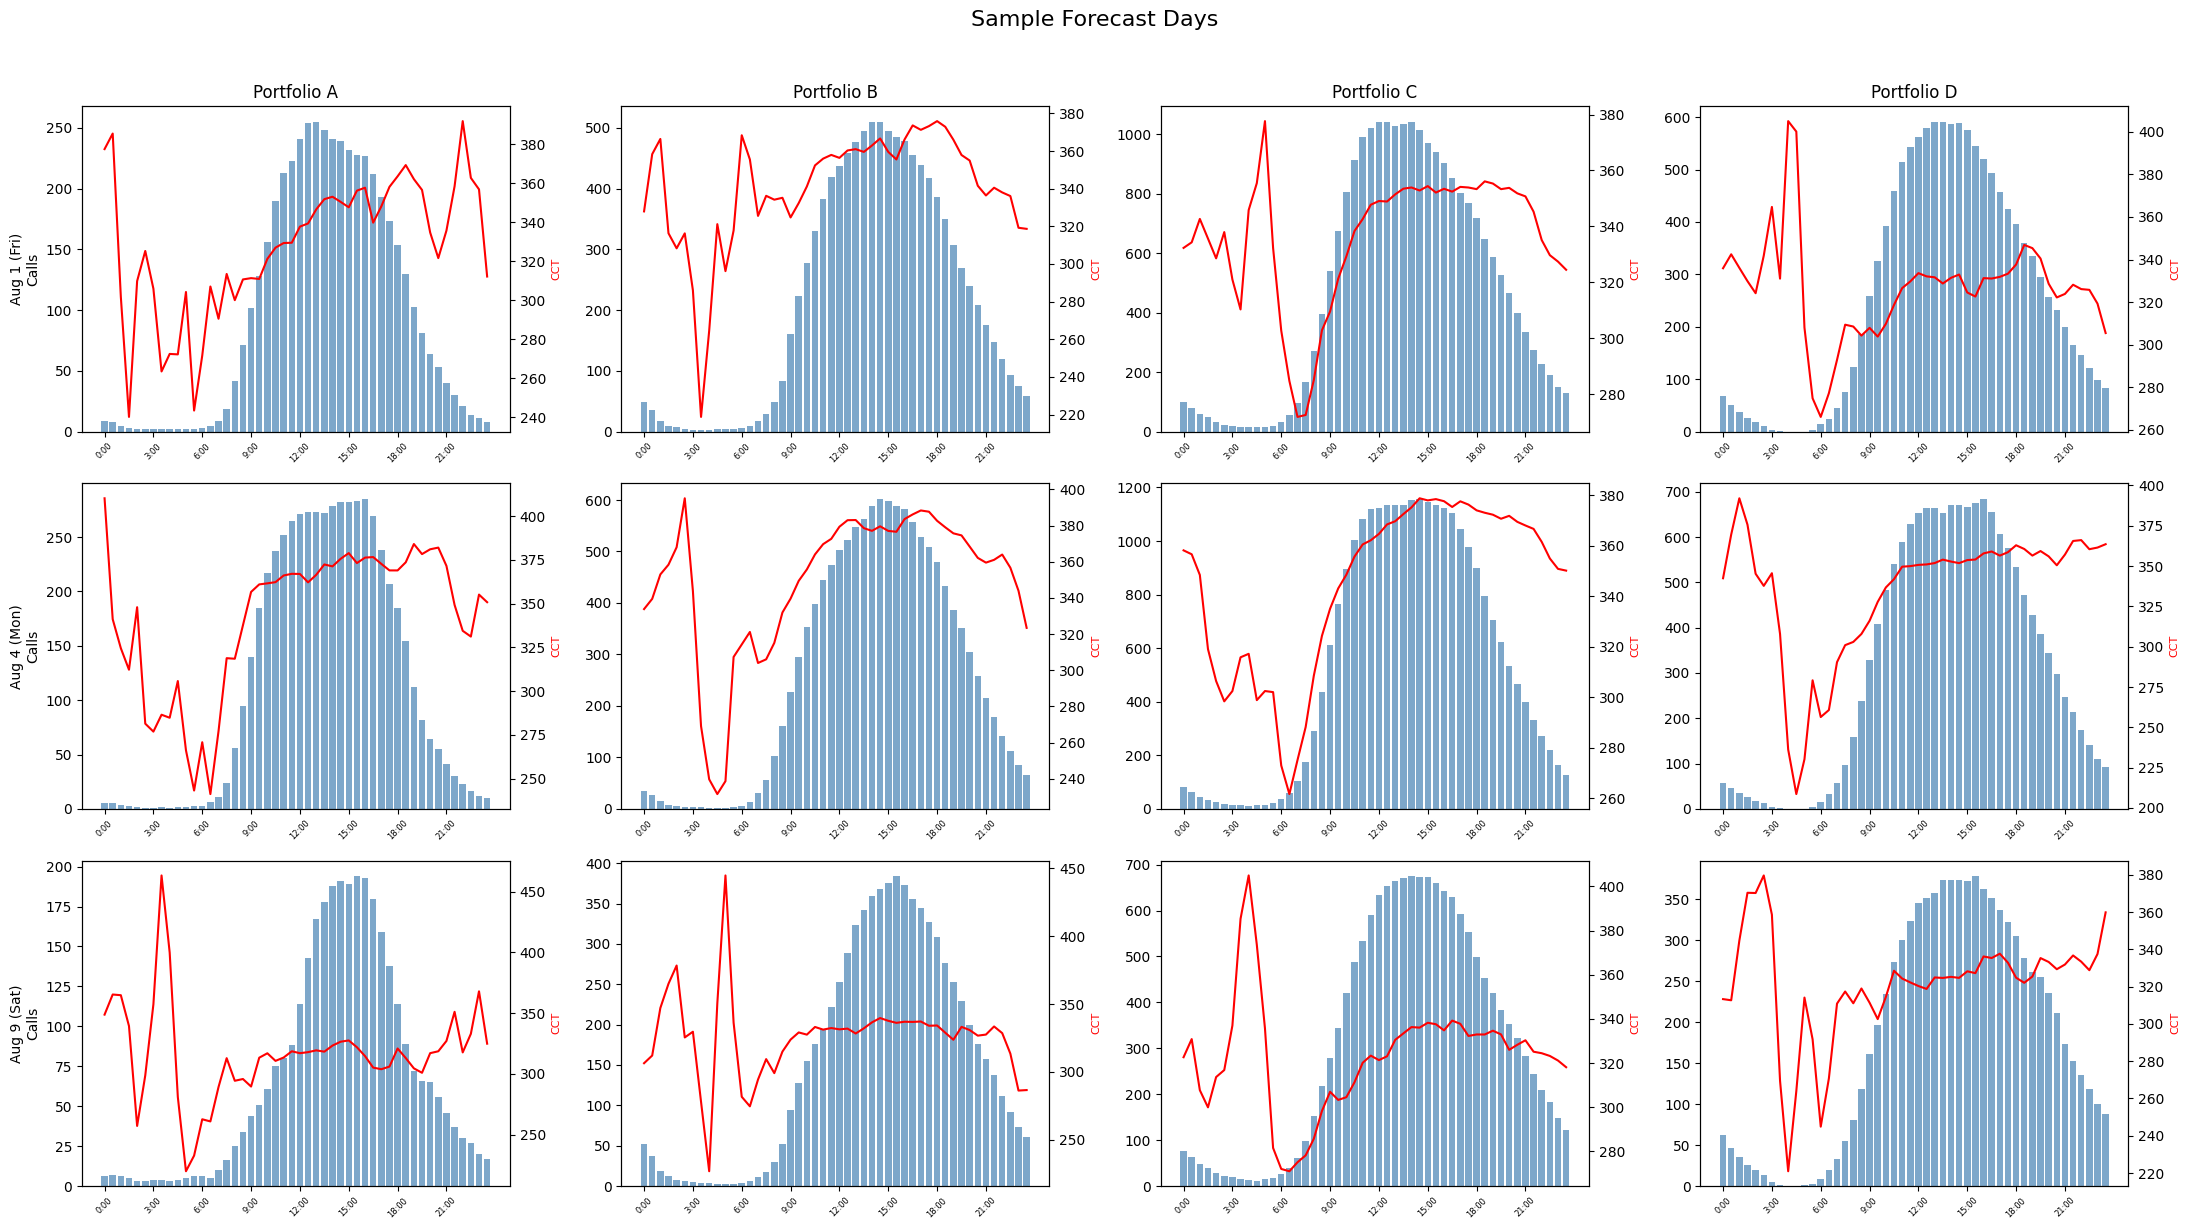

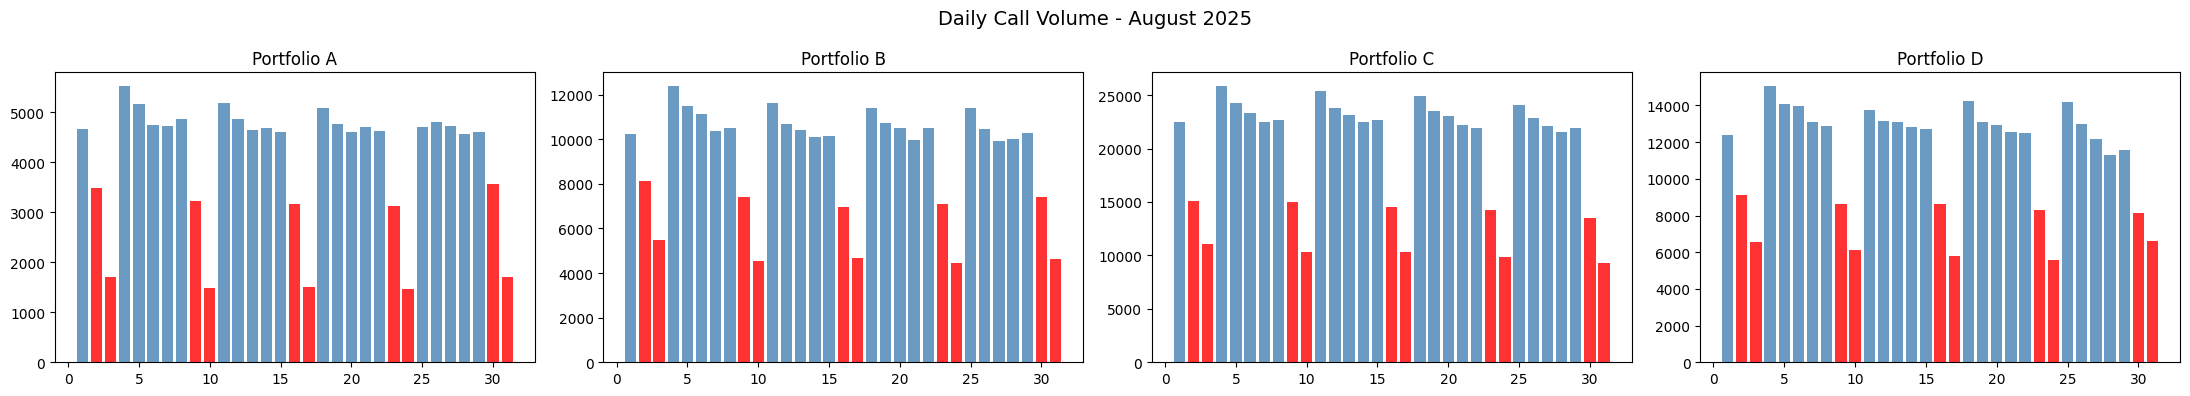


All checks passed! Submission ready: /Users/chideraibe/Documents/Datathon/forecast_v02.csv


In [10]:
# Cell 10: Validation & Plots
print('='*70)
print('VALIDATION')
print('='*70)
assert submission_df.shape == (1488, 19)
print('[PASS] Shape: 1488 x 19')
assert not submission_df.isnull().any().any()
print('[PASS] No nulls')
for p in PORTFOLIOS:
    assert (submission_df[f'Calls_Offered_{p}'] >= 0).all()
    assert (submission_df[f'Abandoned_Calls_{p}'] >= 0).all()
    assert (submission_df[f'Abandoned_Calls_{p}'] <= submission_df[f'Calls_Offered_{p}']).all()
    assert (submission_df[f'Abandoned_Rate_{p}'] <= 1).all()
    assert (submission_df[f'CCT_{p}'] >= 0).all()
print('[PASS] All constraints satisfied')

print('\n--- Aug 2025 Forecast vs Aug 2024 Actual ---')
for p in PORTFOLIOS:
    aug24 = daily_data[p][(daily_data[p]['Date'].dt.month==8) & (daily_data[p]['Date'].dt.year==2024)]
    fc = submission_df[f'Calls_Offered_{p}'].sum()
    ac = aug24['Call Volume'].sum() if len(aug24)>0 else 0
    print(f'  {p}: Forecast={fc:,}, Aug2024={ac:,}, Ratio={fc/ac:.3f}' if ac>0 else f'  {p}: Forecast={fc:,}')

fig, axes = plt.subplots(3, 4, figsize=(22, 12))
fig.suptitle('Sample Forecast Days', fontsize=16, y=1.02)
for ri, (di, lbl) in enumerate(zip([0,3,8], ['Aug 1 (Fri)','Aug 4 (Mon)','Aug 9 (Sat)'])):
    for ci, p in enumerate(PORTFOLIOS):
        ax = axes[ri, ci]
        ax.bar(range(48), interval_forecasts[p]['cv'][di], alpha=0.7, color='steelblue')
        ax2 = ax.twinx()
        ax2.plot(range(48), interval_forecasts[p]['cct'][di], color='red', linewidth=1.5)
        ax2.set_ylabel('CCT', fontsize=8, color='red')
        if ri==0: ax.set_title(f'Portfolio {p}')
        if ci==0: ax.set_ylabel(f'{lbl}\nCalls')
        ax.set_xticks(range(0,48,6))
        ax.set_xticklabels([time_labels_48[i] for i in range(0,48,6)], rotation=45, fontsize=6)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(22, 4))
fig.suptitle('Daily Call Volume - August 2025', fontsize=14)
for ci, p in enumerate(PORTFOLIOS):
    totals = interval_forecasts[p]['cv'].sum(axis=1)
    colors = ['red' if aug_dates[i].dayofweek>=5 else 'steelblue' for i in range(31)]
    axes[ci].bar(range(1,32), totals, color=colors, alpha=0.8)
    axes[ci].set_title(f'Portfolio {p}')
plt.tight_layout()
plt.show()
print('\nAll checks passed! Submission ready:', output_path)